# 重現性設定

In [1]:
import os
import numpy as np
import random
import tensorflow as tf

# 設定環境變數
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'

# 設定執行緒
try:
    tf.config.threading.set_inter_op_parallelism_threads(1)
    tf.config.threading.set_intra_op_parallelism_threads(1)
except RuntimeError as e:
    print(f"警告：設定失敗，原因可能是環境已初始化。{e}")

# 設定所有隨機種子
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("環境配置完成！")

環境配置完成！


# 載入資料集與預處理

In [2]:
from tensorflow.keras.datasets import cifar10

(X_train_image, y_train_label), (X_test_image, y_test_label) = cifar10.load_data()

# reshape 轉成1維
y_train_label = y_train_label.reshape(-1)
y_test_label = y_test_label.reshape(-1)

# 進行標準化
X_train_normalize = X_train_image.astype('float32') / 255.0
X_test_normalize = X_test_image.astype('float32') / 255.0

# One-hot Encoding處理
from tensorflow.keras import utils

y_train_onehot = utils.to_categorical(y_train_label)
y_test_onehot = utils.to_categorical(y_test_label)

print('Train Data images:',X_train_normalize.shape)
print('Train Data labels:',y_train_onehot.shape)
print('Test Data images:',X_test_normalize.shape)
print('Test Data labels:',y_test_onehot.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 66s 0us/step
Train Data images: (50000, 32, 32, 3)
Train Data labels: (50000, 10)
Test Data images: (10000, 32, 32, 3)
Test Data labels: (10000, 10)


# 建立模型

In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Dropout, Flatten, Dense

model = Sequential()

# 卷積層
model.add(Conv2D(
    filters=32,
    kernel_size=(3,3),
    padding='same',
    input_shape=(32, 32, 3),
    activation='relu'))
# 池化層
model.add(MaxPooling2D(pool_size=(2,2)))

# 卷積層
model.add(Conv2D(
    filters=64,
    kernel_size=(3,3),
    padding='same',
    activation='relu'))
# 池化層
model.add(MaxPooling2D(pool_size=(2,2)))

# 卷積層
model.add(Conv2D(
    filters=128,
    kernel_size=(3,3),
    padding='same',
    activation='relu'))
# 池化層
model.add(MaxPooling2D(pool_size=(2,2)))

# 平坦層
model.add(Flatten())
# 隱藏層
model.add(Dense(128, activation='relu'))
# 輸出層
model.add(Dense(10, activation='softmax'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,810 (1.36 MB)

 Trainable params: 356,810 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

# EarlyStopping與ModelCheckpoint

In [5]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=15,
    mode='min',)

In [6]:
!mkdir Model

In [7]:
filepath = 'Model/cifar10_model.h5'
checkpoint = ModelCheckpoint(
    filepath=filepath,
    monitor='val_acc',
    save_best_only=True,
    mode='max')

In [9]:
model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['acc'])

train_history = model.fit(
    x=X_train_normalize,
    y=y_train_onehot,
    validation_split=0.2,
    epochs=200,
    batch_size=200,
    verbose=2,
    callbacks=[early_stopping,checkpoint])

Epoch 1/200


200/200 - 10s - 50ms/step - acc: 0.3947 - loss: 1.6462 - val_acc: 0.4978 - val_loss: 1.3934
Epoch 2/200


200/200 - 2s - 11ms/step - acc: 0.5549 - loss: 1.2490 - val_acc: 0.5892 - val_loss: 1.1741
Epoch 3/200


200/200 - 2s - 11ms/step - acc: 0.6229 - loss: 1.0741 - val_acc: 0.6399 - val_loss: 1.0465
Epoch 4/200


200/200 - 2s - 12ms/step - acc: 0.6623 - loss: 0.9705 - val_acc: 0.6634 - val_loss: 0.9791
Epoch 5/200


...

200/200 - 2s - 12ms/step - acc: 0.7291 - loss: 0.7785 - val_acc: 0.6899 - val_loss: 0.8865
Epoch 8/200


200/200 - 2s - 12ms/step - acc: 0.7510 - loss: 0.7232 - val_acc: 0.7015 - val_loss: 0.8607
Epoch 9/200


200/200 - 2s - 11ms/step - acc: 0.7667 - loss: 0.6779 - val_acc: 0.7070 - val_loss: 0.8469
Epoch 10/200


200/200 - 3s - 13ms/step - acc: 0.7822 - loss: 0.6328 - val_acc: 0.7123 - val_loss: 0.8403
Epoch 11/200
200/200 - 2s - 11ms/step - acc: 0.7962 - loss: 0.5948 - val_acc: 0.7118 - val_loss: 0.8751
Epoch 12/200


200/200 - 2s - 11ms/step - acc: 0.8098 - loss: 0.5564 - val_acc: 0.7258 - val_loss: 0.8501
Epoch 13/200
200/200 - 2s - 11ms/step - acc: 0.8210 - loss: 0.5218 - val_acc: 0.7176 - val_loss: 0.8797
Epoch 14/200
200/200 - 2s - 11ms/step - acc: 0.8288 - loss: 0.5007 - val_acc: 0.7093 - val_loss: 0.9255
Epoch 15/200
200/200 - 2s - 12ms/step - acc: 0.8407 - loss: 0.4649 - val_acc: 0.7147 - val_loss: 0.9236
Epoch 16/200
200/200 - 2s - 12ms/step - acc: 0.8498 - loss: 0.4322 - val_acc: 0.7184 - val_loss: 0.9321
Epoch 17/200
200/200 - 2s - 11ms/step - acc: 0.8556 - loss: 0.4129 - val_acc: 0.7097 - val_loss: 0.9926
Epoch 18/200
200/200 - 2s - 11ms/step - acc: 0.8623 - loss: 0.3904 - val_acc: 0.7181 - val_loss: 0.9921
Epoch 19/200
200/200 - 2s - 11ms/step - acc: 0.8744 - loss: 0.3593 - val_acc: 0.7220 - val_loss: 1.0083
Epoch 20/200
200/200 - 2s - 11ms/step - acc: 0.8861 - loss: 0.3298 - val_acc: 0.7173 - val_loss: 1.0648
Epoch 21/200
200/200 - 3s - 14ms/step - acc: 0.8979 - loss: 0.2954 - val_acc:

# 圖形顯示過程

In [10]:
import matplotlib.pyplot as plt

def show_train_history(train_history, train_key, validation_key):
    plt.plot(train_history.history[train_key], '--')
    plt.plot(train_history.history[validation_key])
    plt.title('Train History')
    plt.ylabel(train_key)
    plt.xlabel('Epoch')
    plt.legend(['train', 'validation'], loc='upper left')
    plt.show()

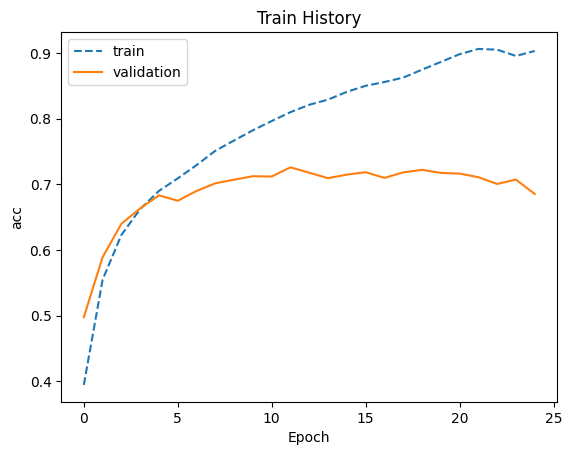

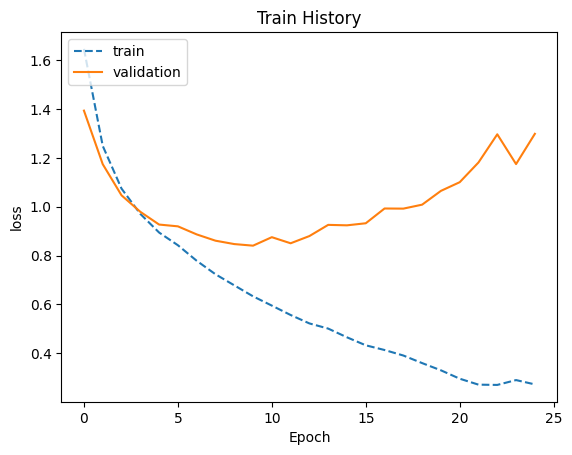

In [11]:
show_train_history(train_history, 'acc', 'val_acc')
show_train_history(train_history, 'loss', 'val_loss')

# 測試模型

In [12]:
scores = model.evaluate(X_test_normalize, y_test_onehot, verbose=2)
print('Test Accuracy:', scores[1])
print('Test Loss:', scores[0])

313/313 - 1s - 4ms/step - acc: 0.6793 - loss: 1.3253
Test Accuracy: 0.6793000102043152
Test Loss: 1.3253048658370972


# 載入最佳模型

In [13]:
model.load_weights('Model/cifar10_model.h5')

scores = model.evaluate(X_test_normalize, y_test_onehot, verbose=2)

313/313 - 1s - 4ms/step - acc: 0.7158 - loss: 0.8812
